# Code to train Rank Reduction Autoencoder
In this notebook we train a Rank Reduction Autoencoder (RRAE) on the generated Gaussian dataset.

The RRAE is exactly the same as the Autoencoder of "train_baseline.ipynb" but with an 
additional rr_layer in the latent space to show its effect (only one line is different 
in the model)

Please make sure to run "generated_data.ipynb" first to generate the dataset.

In [78]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

# Loading the data
try:
    npzfile = np.load('generated_data.npz')
    x_train = torch.from_numpy(npzfile['x_train']).float()
    y_train = torch.from_numpy(npzfile['y_train']).float()
except FileNotFoundError:
    print("generated_data.npz not found. Please run the data generation script first.")
    raise

# Creating DataLoader
batch_size = 32

train_loader = DataLoader(
    TensorDataset(x_train),
    batch_size=batch_size,
    shuffle=True,
)

In [ ]:
import torch.nn as nn
from RR_layer import RRLayer

# Creating the model - Typical CNN autoencoder
class RRAE_ConvAutoEncoder(nn.Module):
    def __init__(self, latent_dim=32, rank=2):
        super().__init__()

        # --------------------------
        # Encoder (CNN → flatten)
        # --------------------------
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),   # 64 → 32
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),  # 32 → 16
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 16 → 8
            nn.ReLU(),
        )

        self.flatten = nn.Flatten()

        self.encoder_fc = nn.Sequential(
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

        # --------------------------
        # Decoder (MLP → reshape → CNN)
        # --------------------------
        self.rr = RRLayer(rank=rank)

        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32 * 8 * 8),
            nn.ReLU(),
        )

        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 8 → 16
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=1),   # 16 → 32
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, kernel_size=3, stride=2, padding=1, output_padding=1),    # 32 → 64
        )

    def encode(self, x, return_factors=False):
        z = self.encoder_cnn(x)
        z = self.flatten(z)
        z = self.encoder_fc(z)
        z = self.rr(z, return_factors=return_factors)
        return z
    
    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(z.size(0), 32, 8, 8)
        x = self.decoder_cnn(x)
        return x
    
    def decode_coeffs(self, coeffs):
        # this function decodes the reduced coefficients from the RR layer
        try:
            lat = self.rr.inference_basis @ coeffs # reconstruct the latent representation from the coefficients
        except AttributeError:
            raise AttributeError("The RR layer does not have an inference basis. Make sure to say model.ev")
        x = self.decode(lat.T) # since basis of shape (L x k), and coeffs of shape (k x N), we need to transpose to get N to the first dimension
        return x
    
    def forward(self, x):
        B = x.shape[0]

        z = self.encode(x)

        x = self.decode(z)

        return x

In [80]:
# Setup for training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RRAE_ConvAutoEncoder(latent_dim=200, rank=2).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_fn = nn.MSELoss()

In [81]:
# Training Loop
epochs = 200

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for (x,) in train_loader:
        x = x.to(device)

        optimizer.zero_grad()

        x_hat = model(x)

        loss = loss_fn(x_hat, x)

        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)

    train_loss /= len(train_loader.dataset)

    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {train_loss:.6f} | "
    )

Epoch 001 | Train Loss: 1.044146 | 
Epoch 002 | Train Loss: 0.921619 | 
Epoch 003 | Train Loss: 0.874804 | 
Epoch 004 | Train Loss: 0.841047 | 
Epoch 005 | Train Loss: 0.794596 | 
Epoch 006 | Train Loss: 0.759261 | 
Epoch 007 | Train Loss: 0.618041 | 
Epoch 008 | Train Loss: 0.532125 | 
Epoch 009 | Train Loss: 0.489229 | 
Epoch 010 | Train Loss: 0.458130 | 
Epoch 011 | Train Loss: 0.427543 | 
Epoch 012 | Train Loss: 0.395972 | 
Epoch 013 | Train Loss: 0.373333 | 
Epoch 014 | Train Loss: 0.343701 | 
Epoch 015 | Train Loss: 0.340963 | 
Epoch 016 | Train Loss: 0.277031 | 
Epoch 017 | Train Loss: 0.241587 | 
Epoch 018 | Train Loss: 0.223390 | 
Epoch 019 | Train Loss: 0.212392 | 
Epoch 020 | Train Loss: 0.204736 | 
Epoch 021 | Train Loss: 0.195814 | 
Epoch 022 | Train Loss: 0.194042 | 
Epoch 023 | Train Loss: 0.180285 | 
Epoch 024 | Train Loss: 0.172422 | 
Epoch 025 | Train Loss: 0.173527 | 
Epoch 026 | Train Loss: 0.164350 | 
Epoch 027 | Train Loss: 0.169757 | 
Epoch 028 | Train Loss: 0.16

In [86]:
# Save the trained model
torch.save(model.state_dict(), "RRAE.pth")

# DO NOT FORGET THIS, the behavior of the RR layer is different in training and inference mode. 
# In training mode, it will perform the SVD and truncate it to a rank k
# In inference mode, it will use the learned basis to project the latent representation to a lower-dimensional space.
model.eval() 


RRAE_ConvAutoEncoder(
  (encoder_cnn): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (encoder_fc): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=200, bias=True)
  )
  (rr): RRLayer(rank=2, basis_history_size=20)
  (decoder_fc): Sequential(
    (0): Linear(in_features=200, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2048, bias=True)
    (3): ReLU()
  )
  (decoder_cnn): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), p

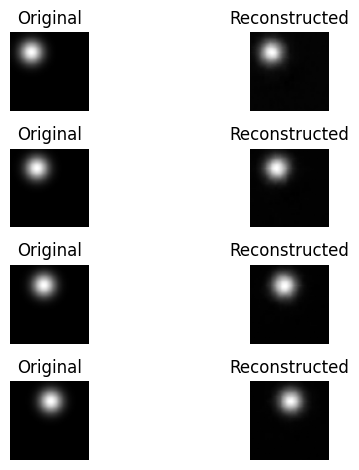

In [87]:
# Some sample reconstructions
import matplotlib.pyplot as plt

pred_test = model(x_train.to(device)).cpu().detach()

idxs = [1, 5, 10, 15]

for i, idx in enumerate(idxs):
    plt.subplot(4, 2, 2*i+1)
    plt.imshow(x_train[idx, 0].cpu().numpy(), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(4, 2, 2*i+2)
    plt.imshow(pred_test[idx, 0].cpu().numpy(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

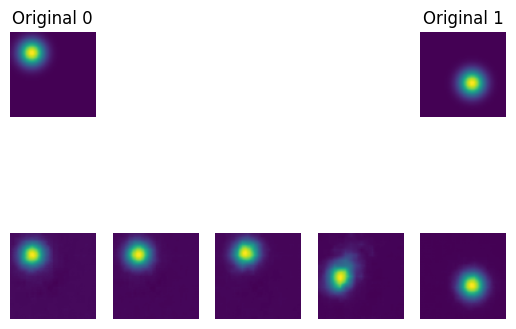

In [96]:
# Evaluating the quality of the latent space

# First test: Interpolation between two points in the latent space

idx_0 = 0
idx_1 = 600

lat_0 = model.encode(x_train[idx_0:idx_0+1].to(device)).cpu().detach()
lat_1 = model.encode(x_train[idx_1:idx_1+1].to(device)).cpu().detach()

lat_interp = torch.stack([lat_0 + (lat_1 - lat_0) * alpha for alpha in np.linspace(0, 1, 5)], dim=0)

res_interp = model.decode(lat_interp.to(device)).cpu().detach()

plt.subplot(2, res_interp.shape[0], 1)
plt.imshow(x_train[idx_0, 0].cpu().numpy())
plt.axis('off')
plt.title("Original 0")

plt.subplot(2, res_interp.shape[0], res_interp.shape[0])
plt.imshow(x_train[idx_1, 0].cpu().numpy())
plt.axis('off')
plt.title("Original 1")

for i in range(res_interp.shape[0]):
    plt.subplot(2, res_interp.shape[0], res_interp.shape[0] + i + 1)
    plt.imshow(res_interp[i, 0].cpu().numpy())
    plt.axis('off')

plt.savefig(f"interpolation_RRAE.png")
plt.show()


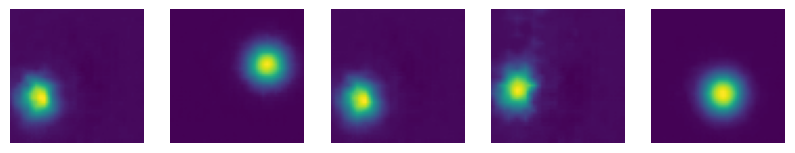

In [89]:
# Second test: Random sampling in the latent space
# Note: when you say return_factors=True, the RR layer returns a tuple (latent, basis, coeffs)
# where coeffs is the reduced representation, and latent = basis @ coeffs
# coeffs is of shape (k x N) and basis is of shape (L x N)
# where N is the number of samples, k is the rank of the RR layer, and L is the latent dimension
with torch.no_grad():
    _, basis, alphas = model.encode(x_train, return_factors=True)
    mins = alphas.min(dim=-1, keepdim=True).values
    maxs = alphas.max(dim=-1, keepdim=True).values
    random_alphas = torch.rand(alphas.shape[0], 5) * (maxs - mins) + mins
    # Note: use decode_coeffs if you want to decode from the reduced representation (coeffs) instead of the full latent representation
    random_samples = model.decode_coeffs(random_alphas.to(device)).cpu().detach()

plt.figure(figsize=(10, 2))
for i in range(random_samples.shape[0]):
    plt.subplot(1, random_samples.shape[0], i + 1)
    plt.imshow(random_samples[i, 0].cpu().numpy())
    plt.axis('off')
plt.savefig(f"random_sample_RRAE.png")